# Multiple Linear Regression

- #### Using Dataset: economic_index
---

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


#### Data Loading & Cleaning

In [13]:
df = pd.read_csv("economic_index.csv")
df.head(2)
df.drop(columns=["Unnamed: 0", "year", "month"], axis=1, inplace=True)
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

---
#### Visualization

- Corr
- more deep
- **regplot**
---

                   interest_rate  unemployment_rate  index_price
interest_rate           1.000000          -0.925814     0.935793
unemployment_rate      -0.925814           1.000000    -0.922338
index_price             0.935793          -0.922338     1.000000


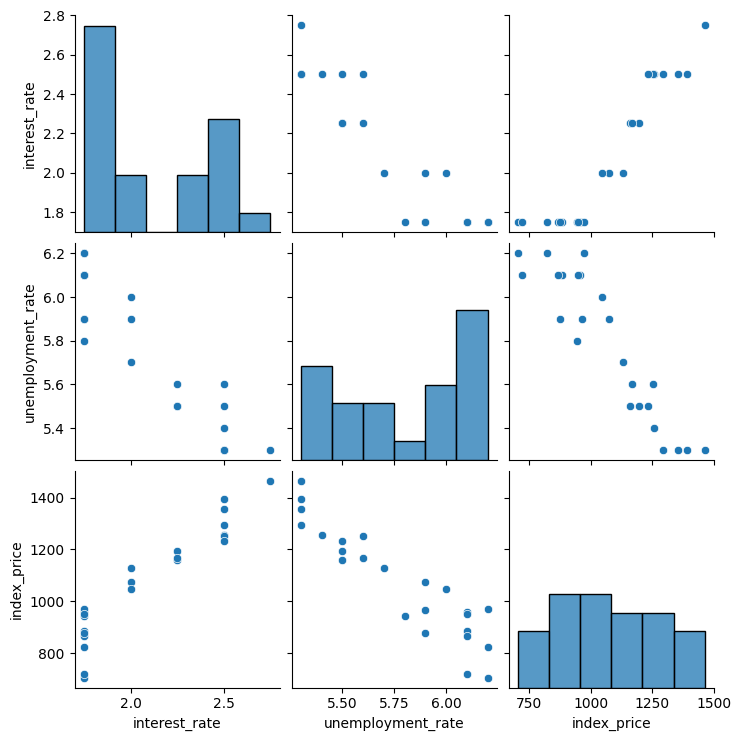

In [14]:
import seaborn as sns
print(df.corr())
sns.pairplot(df)

---

Text(0, 0.5, 'Unemployment Rate')

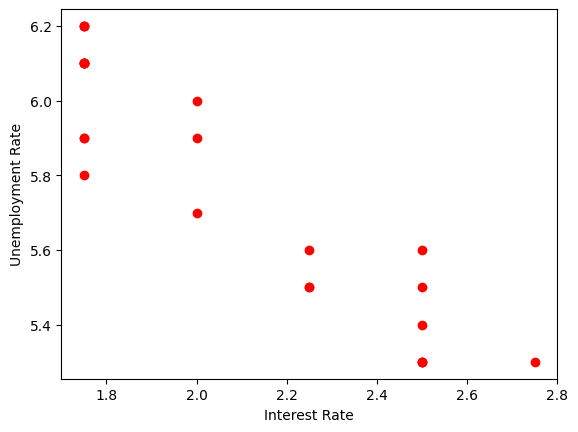

In [20]:
# Visualizing datapoints

plt.scatter(df['interest_rate'], df['unemployment_rate'], color='r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

---

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

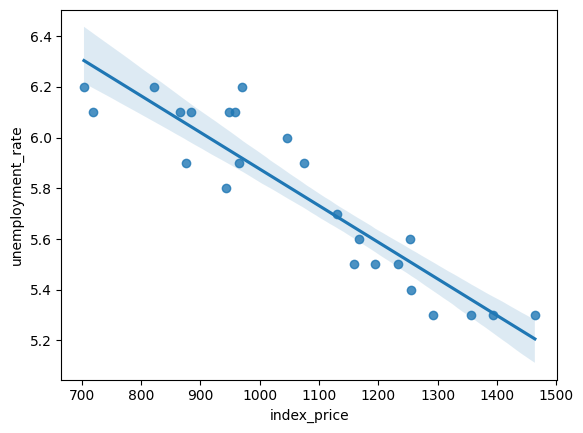

In [27]:
import seaborn as sns
sns.regplot(x=df['index_price'],y= df['unemployment_rate'])

---

### Independent and Dependent feature Split

In [ ]:
# X = df[['interest_rate', 'unemployment_rate']]

X = df.iloc[:,:-1]
y = df.iloc[:,-1]


0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

---
### Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

---
### Standarization

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---
### Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


---
### Cross Validation

- Let Dataset = 900_Train + 100_Test
- Cross_Validation = 900_train = a>Train b>Validation
- Parameter: "cv=5" means, 900_Train / 5
- results: 180 180 180 180 180
- Now, Cross Validation does

1. for cv=1, [test, train, train, train, train]: 180x5
2. for cv=2, [train, test, train, train, train]: 180x5

Similarly for cv=3,4,5

- It returns mse depending on every cv

In [31]:
from sklearn.model_selection import cross_val_score

clf = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)

# clf
np.mean(clf)

np.float64(-5914.828180162386)

---
### Prediction

In [32]:
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

---
### Performance Matrices

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse, mae, rmse)

5793.762887712569 59.935781523235484 76.11677139574805


In [34]:
#display R-squared
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

0.8278978091457145


In [35]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7131630152428576